In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from numpy.random import choice

In [2]:
import emcee
import pymc

In [3]:
from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy


In [4]:
path = '../solutions/transient.npy'

In [5]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])



<ErrorbarContainer object of 3 artists>

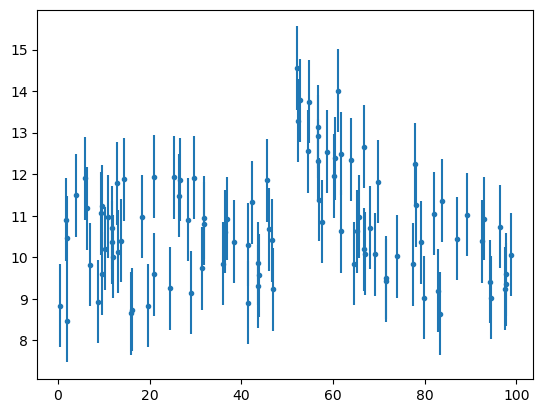

In [6]:
plt.errorbar(times,F,sF,linestyle='',fmt='.')

In [7]:
#data[1] flux, data[2] err on flux

In [8]:
theta0 = np.array([5,10,50,0.1]) #initial guess for A,b,t0,alpha

In [9]:
Amin, Amax = 0, 50
bmin, bmax = 0, 50
t0min, t0max = 0, 100
alphamin, alphamax = np.exp(-5),np.exp(5)

In [10]:
def b_model(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [11]:
def log_likelihood(theta, x, y, yerr):
    A,b,t0,alpha = theta
    y_model = b_model(theta,x)

    return -0.5 * np.sum((y - y_model) ** 2 / yerr**2 )
        
def log_prior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return - np.log(alpha) # for scale invariance: Prior uniform in ln(alpha) --> proportional to 1/alpha
    return -np.inf
                   
def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [12]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**
pos = theta0 + 1e-1 * np.random.randn(nwalkers, ndim) # initial states for each walker --> dim (20,4)

In [13]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(times, F, sF)
)

In [14]:
sampler.run_mcmc(pos, nsteps, progress=True)

  0%|                                                                                         | 0/10000 [00:00<?, ?it/s]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1632.91it/s]


State([[ 5.66771195 10.22258562 49.05066335  0.12477143]
 [ 4.63029953 10.40115771 49.44704309  0.11763881]
 [ 3.84071169 10.37482856 50.13818852  0.10341353]
 [ 4.24690846 10.20025282 50.38487844  0.10407899]
 [ 5.70801729 10.1688051  47.9037042   0.10433537]
 [ 4.46073675 10.11287761 51.54176779  0.12540731]
 [ 4.65719283 10.51853846 48.77253396  0.13678701]
 [ 4.97920082 10.10961442 50.12410078  0.10520316]
 [ 3.8960779  10.00540694 52.13516796  0.09686655]
 [ 6.62969751 10.37122505 49.90757404  0.18445471]
 [ 5.04709863 10.2270663  51.26554026  0.13989911]
 [ 4.18003172 10.05361368 51.83415112  0.1044578 ]
 [ 8.97682537 10.25950465 47.84006424  0.14596218]
 [ 4.54425001 10.32386007 50.69451498  0.11768563]
 [ 5.51332904 10.29125627 49.07498924  0.11196041]
 [ 4.44555649 10.26693597 50.48950885  0.12032791]
 [ 5.20721206 10.12602035 49.81916646  0.13651113]
 [ 3.66026998 10.40596651 51.08596661  0.11544906]
 [ 3.94463798 10.31047144 50.68648091  0.13392948]
 [ 3.78009894 10.48315507

In [15]:
sampler.acceptance_fraction # just a bit above 50% could spare slightly larger steps?

array([0.5471, 0.5393, 0.5301, 0.5335, 0.5447, 0.5272, 0.5314, 0.5281,
       0.5415, 0.5342, 0.5289, 0.5255, 0.5383, 0.5324, 0.5451, 0.5337,
       0.528 , 0.5358, 0.5171, 0.5489])

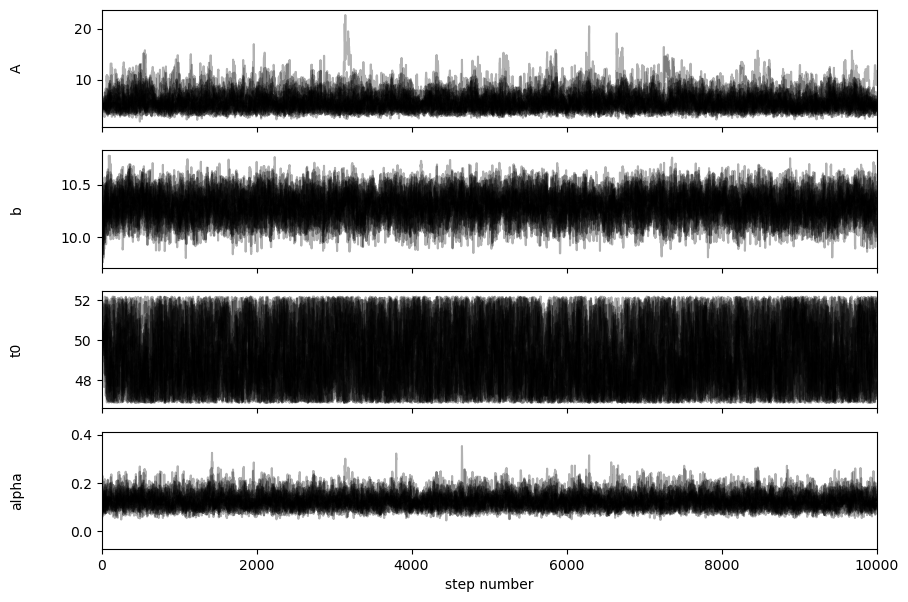

In [16]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain() # dim (nsteps,nwalkers,ndim) = (10000, 20, 4)
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [17]:
tau = sampler.get_autocorr_time()
print(tau)

[79.39696011 58.56649485 79.96607851 64.9035195 ]


In [18]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #chain thinned based on the largest correletion length and burn-in set to 3* largest correletion length
print(flat_samples.shape)

(2460, 4)


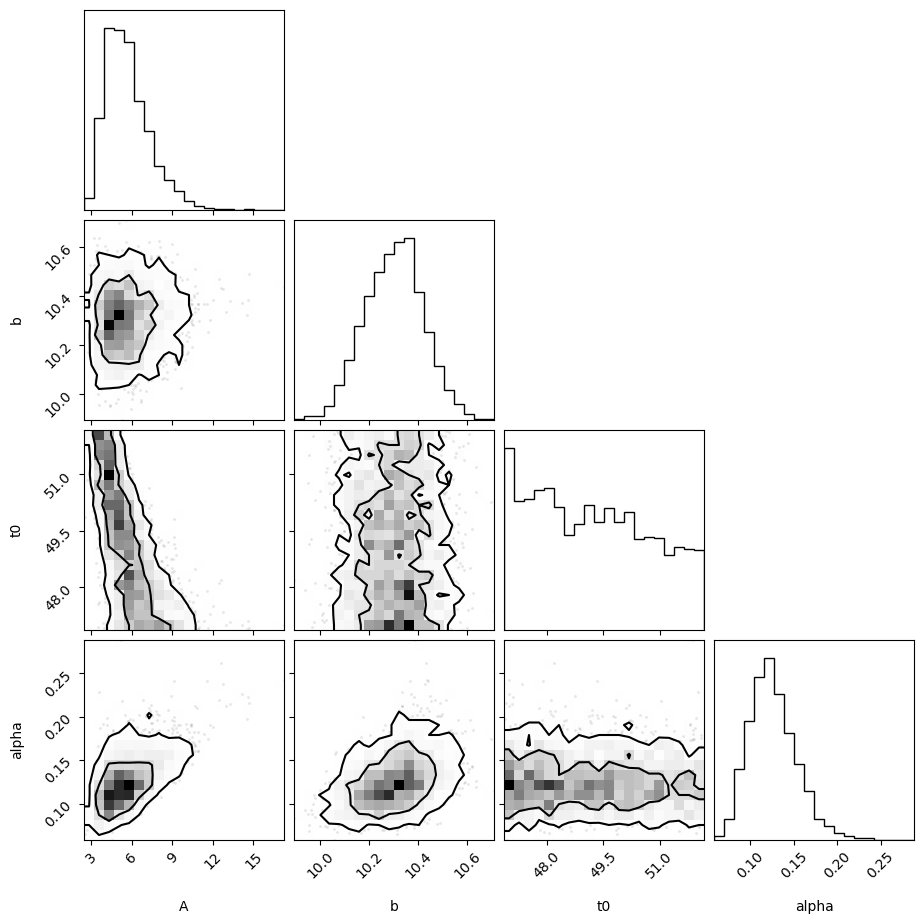

In [19]:
import corner
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95]) #contours at 68 and 95%

In [20]:
# 100 samples randomly from your burned, thinned chain and plot the 100 corresponding burst time-series on a figure along with the original data
chosen_samples= flat_samples[np.random.choice(len(flat_samples),size=100)]

Text(0, 0.5, 'flux')

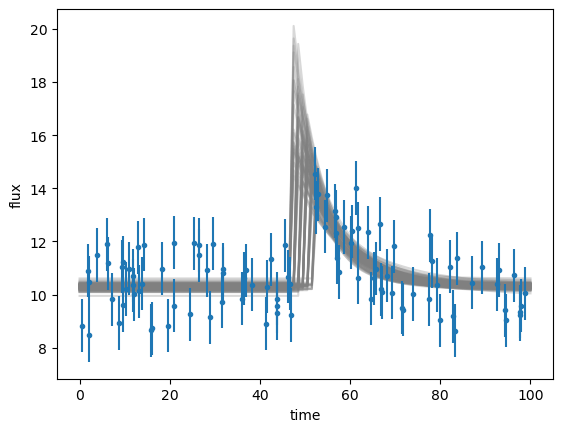

In [21]:
tgrid=np.linspace(0,100,100)

for chosen_theta in chosen_samples:
    ygrid =  b_model(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(times,F,yerr=sF,fmt='.')
plt.xlabel("time")
plt.ylabel("flux")

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [5,50,95]) # 50th percentile = median, 95-5 = 90% credibility 
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>